# Optativa III: Ciencia de Datos
## Actividad práctica — Estadística descriptiva e inferencial con `scipy.stats`

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 2**

---

### Propósito de la actividad

En esta actividad calcularás **medidas de tendencia central y dispersión**, generarás y visualizarás las distribuciones **normal, binomial y Poisson**, y comprobarás de forma empírica el **teorema del límite central**.

No se trata solo de ejecutar el código: en cada bloque encontrarás **preguntas** y **retos de modificación**. Debes cambiar valores, volver a ejecutar y explicar qué observas. El aprendizaje ocurre cuando experimentas.

### Cómo trabajar en Google Colab

1. Abre este archivo en [Google Colab](https://colab.research.google.com) (Archivo → Subir cuaderno).
2. Ejecuta cada celda de código con **Shift + Enter**, en orden.
3. Responde las preguntas en las celdas de texto marcadas con ✍️ (haz doble clic para editar).
4. Al terminar, ve a **Archivo → Guardar una copia en Drive**, y entrega el enlace en Classroom.

> **Importante:** ejecuta las celdas en orden. Si una falla, revisa que hayas corrido las anteriores.


---
## Paso 0 — Preparación del entorno

Importamos las librerías. En Colab ya vienen instaladas, así que solo hay que importarlas.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Semilla para que los resultados aleatorios sean reproducibles
# (todos obtendran los mismos numeros al usar la misma semilla)
np.random.seed(42)

print("Librerias cargadas correctamente.")
print("Version de numpy:", np.__version__)

Librerias cargadas correctamente.
Version de numpy: 2.5.2


> ✍️ **Pregunta 0.1** — ¿Para qué sirve `np.random.seed(42)`? ¿Qué pasaría si cada estudiante usara una semilla distinta al comparar resultados?

**Respuesta:** Fija el generador de números aleatorios para que siempre produzca la misma secuencia. Así los resultados son reproducibles: todos en el grupo obtenemos los mismos números y podemos comparar. Si cada estudiante usara una semilla distinta, a cada quien le saldrían datos diferentes y no se podría saber si una diferencia viene del código o simplemente del azar.

---
## Paso 1 — Medidas de tendencia central y dispersión

Vamos a simular las **calificaciones finales de un grupo de 40 estudiantes**. Primero las creamos y luego las describimos estadísticamente.


In [2]:
# Calificaciones simuladas de 40 estudiantes (escala 0-100)
calificaciones = np.array([
    78, 85, 90, 72, 88, 95, 60, 74, 82, 91,
    68, 77, 84, 79, 93, 70, 86, 81, 75, 89,
    65, 80, 87, 76, 92, 73, 83, 69, 94, 71,
    88, 78, 85, 90, 67, 82, 79, 86, 74, 100
])

print("Numero de estudiantes:", len(calificaciones))
print("Calificaciones:", calificaciones)

Numero de estudiantes: 40
Calificaciones: [ 78  85  90  72  88  95  60  74  82  91  68  77  84  79  93  70  86  81
  75  89  65  80  87  76  92  73  83  69  94  71  88  78  85  90  67  82
  79  86  74 100]


In [3]:
# --- Medidas de TENDENCIA CENTRAL ---
media    = np.mean(calificaciones)
mediana  = np.median(calificaciones)
moda     = stats.mode(calificaciones, keepdims=True)

print("MEDIDAS DE TENDENCIA CENTRAL")
print(f"  Media    (promedio):        {media:.2f}")
print(f"  Mediana  (valor central):   {mediana:.2f}")
print(f"  Moda     (mas frecuente):   {moda.mode[0]}  (aparece {moda.count[0]} veces)")

print()

# --- Medidas de DISPERSION ---
rango       = np.max(calificaciones) - np.min(calificaciones)
varianza    = np.var(calificaciones, ddof=1)   # ddof=1 -> varianza muestral
desv_est    = np.std(calificaciones, ddof=1)   # desviacion estandar muestral
rango_iq    = stats.iqr(calificaciones)        # rango intercuartilico

print("MEDIDAS DE DISPERSION")
print(f"  Rango:                      {rango}")
print(f"  Varianza (muestral):        {varianza:.2f}")
print(f"  Desviacion estandar:        {desv_est:.2f}")
print(f"  Rango intercuartilico (IQR):{rango_iq:.2f}")

MEDIDAS DE TENDENCIA CENTRAL
  Media    (promedio):        80.90
  Mediana  (valor central):   81.50
  Moda     (mas frecuente):   74  (aparece 2 veces)

MEDIDAS DE DISPERSION
  Rango:                      40
  Varianza (muestral):        85.17
  Desviacion estandar:        9.23
  Rango intercuartilico (IQR):14.00


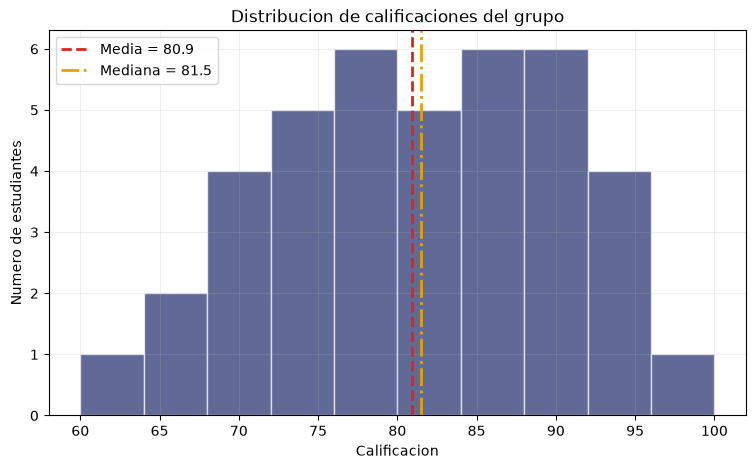

In [4]:
# Visualizamos las calificaciones con un histograma y las medidas centrales
plt.figure(figsize=(9,5))
plt.hist(calificaciones, bins=10, color="#1e2a6b", alpha=0.7, edgecolor="white")
plt.axvline(media,   color="#e2231a", linewidth=2, linestyle="--", label=f"Media = {media:.1f}")
plt.axvline(mediana, color="#e8a200", linewidth=2, linestyle="-.", label=f"Mediana = {mediana:.1f}")
plt.title("Distribucion de calificaciones del grupo")
plt.xlabel("Calificacion")
plt.ylabel("Numero de estudiantes")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

> ✍️ **Pregunta 1.1** — Observa el histograma. ¿La media y la mediana están cerca o lejos entre sí? ¿Qué te dice eso sobre la simetría de las calificaciones?

**Respuesta:** Están muy cerca (media = 80.90, mediana = 81.50). Eso indica que la distribución es aproximadamente simétrica: no hay una cola de valores extremos que jale la media hacia un lado.

> ✍️ **Pregunta 1.2** — ¿Por qué usamos `ddof=1` para la varianza y la desviación estándar? Investiga la diferencia entre varianza **poblacional** y **muestral**.

**Respuesta:** Con `ddof=1` se divide entre n−1 (varianza muestral) en lugar de entre n (poblacional). La poblacional se usa cuando tienes TODOS los datos; aquí los 40 alumnos son una muestra, y al calcular la varianza usando la media de esa misma muestra se subestima la dispersión real. Dividir entre n−1 corrige ese sesgo y da una estimación más honesta de la varianza de la población.

### 🔧 Reto de modificación 1

En la siguiente celda, **agrega un estudiante con una calificación atípica muy baja** (por ejemplo, 10) y observa cómo cambian la media y la mediana.


In [5]:
# RETO: agrega el valor 10 al final del arreglo y vuelve a calcular
# Pista: usa np.append(calificaciones, 10)

calificaciones_con_atipico = np.append(calificaciones, 10)   # <-- modifica este valor y experimenta

print("Sin valor atipico -> Media:", round(np.mean(calificaciones),2),
      " Mediana:", np.median(calificaciones))
print("Con valor atipico -> Media:", round(np.mean(calificaciones_con_atipico),2),
      " Mediana:", np.median(calificaciones_con_atipico))

Sin valor atipico -> Media: 80.9  Mediana: 81.5
Con valor atipico -> Media: 79.17  Mediana: 81.0


> ✍️ **Pregunta 1.3** — ¿Cuál medida cambió más al agregar el valor atípico: la media o la mediana? Con base en esto, ¿cuál medida es más **robusta** ante valores extremos y por qué es importante saberlo al analizar datos reales (por ejemplo, salarios o precios)?

**Respuesta:** Cambió mucho más la media (de 80.90 a 79.17), mientras la mediana casi no se movió (de 81.5 a 81.0). La mediana es más robusta porque solo depende de la posición central de los datos ordenados, no del tamaño de los valores. Esto importa en datos reales como los salarios: unos cuantos sueldos altísimos inflan el promedio y dan una idea falsa de lo que gana la persona típica; la mediana la representa mejor.

---
## Paso 2 — Distribución Normal (Gaussiana)

La distribución normal es la famosa "campana". Se define por su **media (μ)** y su **desviación estándar (σ)**. Muchos fenómenos naturales la siguen.


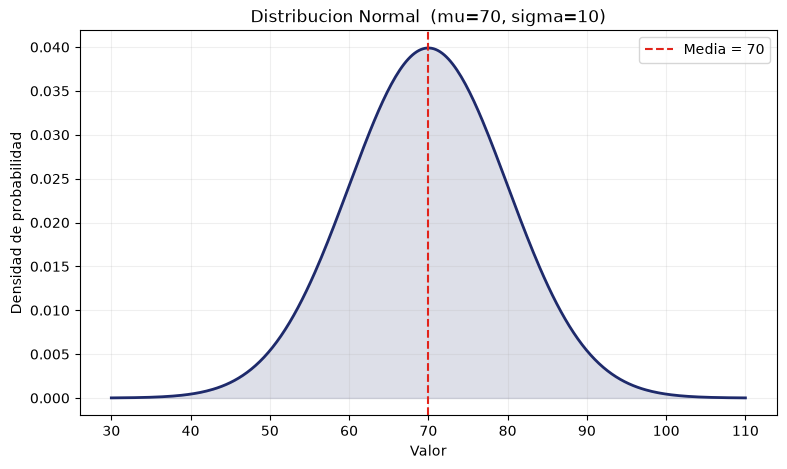

In [6]:
# Parametros de la distribucion normal
mu    = 70    # media
sigma = 10    # desviacion estandar

# Generamos el eje x y la funcion de densidad
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
densidad = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(9,5))
plt.plot(x, densidad, color="#1e2a6b", linewidth=2)
plt.fill_between(x, densidad, alpha=0.15, color="#1e2a6b")
plt.axvline(mu, color="#e2231a", linestyle="--", label=f"Media = {mu}")
plt.title(f"Distribucion Normal  (mu={mu}, sigma={sigma})")
plt.xlabel("Valor")
plt.ylabel("Densidad de probabilidad")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [7]:
# Calculamos probabilidades con la distribucion normal
# Ejemplo: si las calificaciones son Normal(70, 10)...

p_menor_60 = stats.norm.cdf(60, mu, sigma)          # P(X < 60): probabilidad de reprobar
p_mayor_90 = 1 - stats.norm.cdf(90, mu, sigma)      # P(X > 90): probabilidad de excelencia
p_entre    = stats.norm.cdf(80, mu, sigma) - stats.norm.cdf(60, mu, sigma)  # P(60 < X < 80)

print(f"P(calificacion < 60) = {p_menor_60:.3f}  ->  {p_menor_60*100:.1f}% reprobaria")
print(f"P(calificacion > 90) = {p_mayor_90:.3f}  ->  {p_mayor_90*100:.1f}% excelencia")
print(f"P(60 < calif < 80)   = {p_entre:.3f}  ->  {p_entre*100:.1f}% en rango medio")

P(calificacion < 60) = 0.159  ->  15.9% reprobaria
P(calificacion > 90) = 0.023  ->  2.3% excelencia
P(60 < calif < 80)   = 0.683  ->  68.3% en rango medio


> ✍️ **Pregunta 2.1** — Ejecuta la celda con `mu=70` y `sigma=10`. Ahora cambia `sigma` a **20** y vuelve a ejecutar ambas celdas. ¿La campana se vuelve más ancha o más angosta? ¿Qué significa eso en términos de la variabilidad de las calificaciones?

**Respuesta:** Con `sigma=20` la campana se vuelve más ancha y más baja. Significa que hay más variabilidad: las calificaciones se alejan más de la media, es decir, el grupo es más disparejo. Con sigma pequeña pasa lo contrario: casi todos calificarían cerca del promedio.

> ✍️ **Pregunta 2.2** — Con `mu=70, sigma=10`, ¿qué porcentaje de estudiantes reprobaría (calificación menor a 60)? ¿Y si el profesor mejora su enseñanza y ahora `mu=78`? Modifica el valor, ejecuta y anota ambos resultados.

**Respuesta:** Con `mu=70` reprobaría el **15.9%** de los estudiantes; con `mu=78` solo el **3.6%**. Subir la media 8 puntos redujo la reprobación a menos de la cuarta parte, porque al recorrer la campana a la derecha queda mucha menos área debajo de 60.

### 🔧 Reto de modificación 2

La **regla empírica** (68-95-99.7) dice que en una normal, aproximadamente el 68% de los datos cae dentro de 1σ de la media, el 95% dentro de 2σ y el 99.7% dentro de 3σ. Compruébalo con código.


In [8]:
# RETO: verifica la regla empirica 68-95-99.7
mu, sigma = 70, 10

for k in [1, 2, 3]:
    limite_inf = mu - k*sigma
    limite_sup = mu + k*sigma
    prob = stats.norm.cdf(limite_sup, mu, sigma) - stats.norm.cdf(limite_inf, mu, sigma)
    print(f"Dentro de {k} sigma  ({limite_inf} a {limite_sup}):  {prob*100:.1f}% de los datos")

Dentro de 1 sigma  (60 a 80):  68.3% de los datos
Dentro de 2 sigma  (50 a 90):  95.4% de los datos
Dentro de 3 sigma  (40 a 100):  99.7% de los datos


> ✍️ **Pregunta 2.3** — ¿Los porcentajes que obtuviste coinciden con la regla 68-95-99.7? Explica con tus palabras por qué esta regla es útil para detectar valores anómalos en un conjunto de datos.

**Respuesta:** Sí, coinciden: salió 68.3%, 95.4% y 99.7%. La regla es útil porque te da un criterio rápido para detectar anomalías: si un dato cae fuera de ±3 desviaciones estándar de la media, está en el 0.3% más raro de los casos. Es tan improbable que casi seguro se trata de un error de captura o de un valor atípico que merece revisarse.

---
## Paso 3 — Distribución Binomial

La binomial modela el **número de éxitos en `n` intentos independientes**, cada uno con probabilidad `p` de éxito. Ejemplo: cuántas preguntas acierta un estudiante en un examen de opción múltiple si responde al azar.


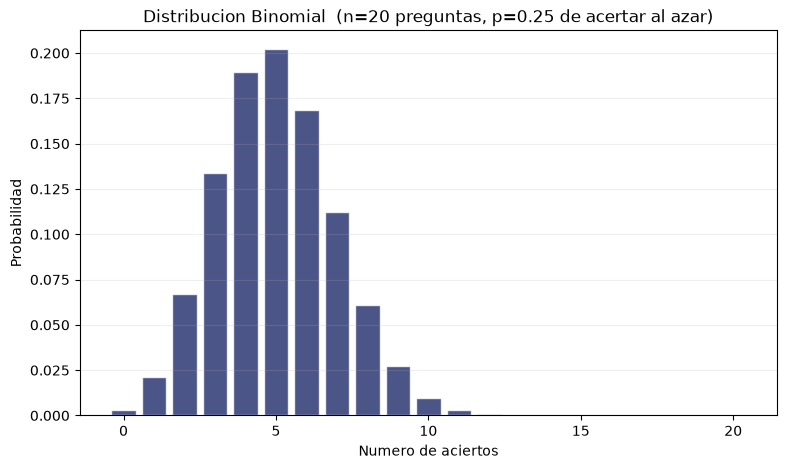

Aciertos esperados (media): 5.00
Desviacion estandar:        1.94


In [9]:
# Un examen de 20 preguntas de opcion multiple (4 opciones -> p=0.25 de acertar al azar)
n = 20      # numero de preguntas
p = 0.25    # probabilidad de acertar cada una al azar

# Numero de aciertos posibles: 0, 1, 2, ..., 20
k = np.arange(0, n+1)
prob_binomial = stats.binom.pmf(k, n, p)

plt.figure(figsize=(9,5))
plt.bar(k, prob_binomial, color="#1e2a6b", alpha=0.8, edgecolor="white")
plt.title(f"Distribucion Binomial  (n={n} preguntas, p={p} de acertar al azar)")
plt.xlabel("Numero de aciertos")
plt.ylabel("Probabilidad")
plt.grid(alpha=0.2, axis="y")
plt.show()

# Valor esperado (media teorica) y desviacion estandar
media_bin = n * p
desv_bin  = np.sqrt(n * p * (1-p))
print(f"Aciertos esperados (media): {media_bin:.2f}")
print(f"Desviacion estandar:        {desv_bin:.2f}")

In [10]:
# Preguntas de probabilidad concretas
p_exactamente_5 = stats.binom.pmf(5, n, p)          # P(exactamente 5 aciertos)
p_aprobar       = 1 - stats.binom.cdf(11, n, p)     # P(12 o mas aciertos) = aprobar con 60%

print(f"P(acertar exactamente 5)      = {p_exactamente_5:.3f}")
print(f"P(aprobar respondiendo al azar) = {p_aprobar:.5f}  ->  {p_aprobar*100:.3f}%")

P(acertar exactamente 5)      = 0.202
P(aprobar respondiendo al azar) = 0.00094  ->  0.094%


> ✍️ **Pregunta 3.1** — Según el resultado, ¿es realista aprobar un examen de 20 preguntas respondiendo completamente al azar? ¿Por qué?

**Respuesta:** No. La probabilidad de aprobar al azar es de apenas **0.094%**, es decir, menos de 1 caso en mil. Lo esperado respondiendo al azar son solo 5 aciertos de 20, y llegar a 12 requeriría una suerte extrema. Estudiar sale mucho más rentable que confiar en el azar.

> ✍️ **Pregunta 3.2** — Cambia `p = 0.25` por `p = 0.5` (como si el examen fuera de verdadero/falso). Vuelve a ejecutar. ¿Cómo cambia la forma de la gráfica y la probabilidad de aprobar?

**Respuesta:** Con `p=0.5` la gráfica se vuelve simétrica y se centra en 10 aciertos (antes estaba cargada hacia 5), y la probabilidad de aprobar al azar sube de 0.094% a **25.2%**: 1 de cada 4 personas aprobaría sin saber nada. Por eso un examen de verdadero/falso es mucho más vulnerable al azar que uno de opción múltiple con 4 opciones.

### 🔧 Reto de modificación 3

Modifica los parámetros para responder: **¿cuántas preguntas de opción múltiple (con p=0.25) necesitaría un examen para que la probabilidad de aprobar al azar sea prácticamente cero?**


In [11]:
# RETO: probamos varios tamanos de examen y observamos como cae la probabilidad
p_prueba = 0.25

for n_prueba in [10, 20, 40, 60, 100]:
    umbral_aprobar = int(n_prueba * 0.6)   # 60% para aprobar
    p_aprobar_azar = 1 - stats.binom.cdf(umbral_aprobar - 1, n_prueba, p_prueba)
    print(f"Con {n_prueba:3d} preguntas, P(aprobar al azar con 60%) = {p_aprobar_azar:.8f}")

Con  10 preguntas, P(aprobar al azar con 60%) = 0.01972771
Con  20 preguntas, P(aprobar al azar con 60%) = 0.00093539
Con  40 preguntas, P(aprobar al azar con 60%) = 0.00000283
Con  60 preguntas, P(aprobar al azar con 60%) = 0.00000001
Con 100 preguntas, P(aprobar al azar con 60%) = 0.00000000


---
## Paso 4 — Distribución de Poisson

La distribución de Poisson modela el **número de eventos que ocurren en un intervalo fijo** de tiempo o espacio, cuando se conoce la tasa promedio (λ, lambda). Ejemplo: número de solicitudes que llegan a un servidor por minuto.


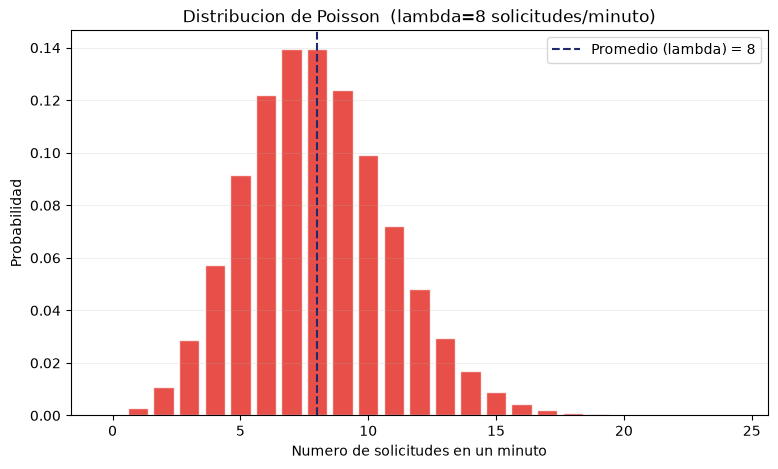

In [12]:
# Un servidor recibe en promedio 8 solicitudes por minuto
lam = 8    # lambda: tasa promedio de eventos

# Numero de solicitudes posibles en un minuto
k = np.arange(0, 25)
prob_poisson = stats.poisson.pmf(k, lam)

plt.figure(figsize=(9,5))
plt.bar(k, prob_poisson, color="#e2231a", alpha=0.8, edgecolor="white")
plt.axvline(lam, color="#1e2a6b", linestyle="--", label=f"Promedio (lambda) = {lam}")
plt.title(f"Distribucion de Poisson  (lambda={lam} solicitudes/minuto)")
plt.xlabel("Numero de solicitudes en un minuto")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(alpha=0.2, axis="y")
plt.show()

In [13]:
# Preguntas de probabilidad para el servidor
p_exactamente_8 = stats.poisson.pmf(8, lam)         # P(exactamente 8)
p_mas_de_15     = 1 - stats.poisson.cdf(15, lam)    # P(mas de 15): riesgo de saturacion
p_cero          = stats.poisson.pmf(0, lam)         # P(ninguna solicitud)

print(f"P(exactamente 8 solicitudes) = {p_exactamente_8:.3f}")
print(f"P(mas de 15 solicitudes)     = {p_mas_de_15:.4f}  ->  riesgo de saturacion")
print(f"P(cero solicitudes)          = {p_cero:.5f}")

P(exactamente 8 solicitudes) = 0.140
P(mas de 15 solicitudes)     = 0.0082  ->  riesgo de saturacion
P(cero solicitudes)          = 0.00034


> ✍️ **Pregunta 4.1** — Si el servidor se satura cuando recibe más de 15 solicitudes por minuto, ¿qué tan frecuente es ese riesgo con λ=8? ¿Recomendarías reforzar el servidor?

**Respuesta:** Con λ=8 la probabilidad de recibir más de 15 solicitudes en un minuto es de **0.82%**, o sea aproximadamente 1 minuto de cada 122. Es un riesgo bajo, así que no urge reforzar el servidor todavía; bastaría con monitorearlo y tener una alerta por si la demanda promedio empieza a subir.

> ✍️ **Pregunta 4.2** — Imagina que el negocio crece y ahora llegan en promedio **15 solicitudes por minuto**. Cambia `lam = 8` por `lam = 15`, ejecuta de nuevo, y compara la probabilidad de saturación. ¿Qué decisión de ingeniería tomarías?

**Respuesta:** Con λ=15 la probabilidad de saturación se dispara de 0.82% a **43.2%**: el servidor estaría saturado casi la mitad del tiempo, porque el umbral de 15 quedó al nivel del promedio. La decisión sería escalar la capacidad antes de llegar a ese punto: agregar servidores con un balanceador de carga (escalamiento horizontal) o subir la capacidad del actual, de modo que el umbral de saturación quede muy por encima de la demanda promedio.

---
## Paso 5 — Teorema del Límite Central (TLC)

Este es el concepto más importante de la semana. El **teorema del límite central** afirma que, si tomamos muchas muestras de cualquier distribución y calculamos sus **medias**, la distribución de esas medias se aproxima a una **normal**, aunque los datos originales no sean normales.

Vamos a comprobarlo empíricamente partiendo de una distribución **claramente NO normal** (uniforme).


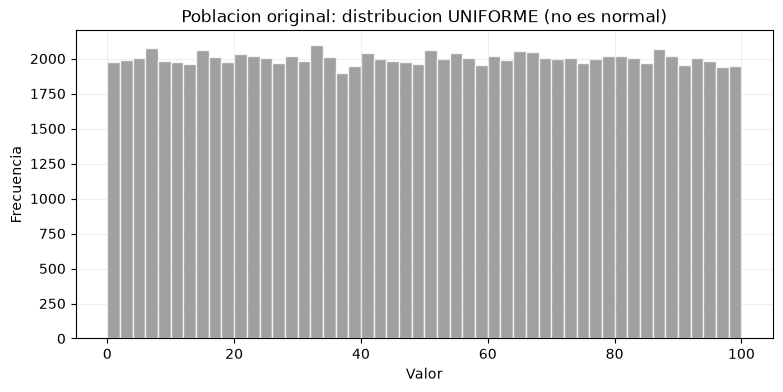

In [14]:
# Partimos de una distribucion UNIFORME (nada parecida a una campana)
poblacion = np.random.uniform(0, 100, 100000)

plt.figure(figsize=(9,4))
plt.hist(poblacion, bins=50, color="#888", alpha=0.8, edgecolor="white")
plt.title("Poblacion original: distribucion UNIFORME (no es normal)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.2)
plt.show()

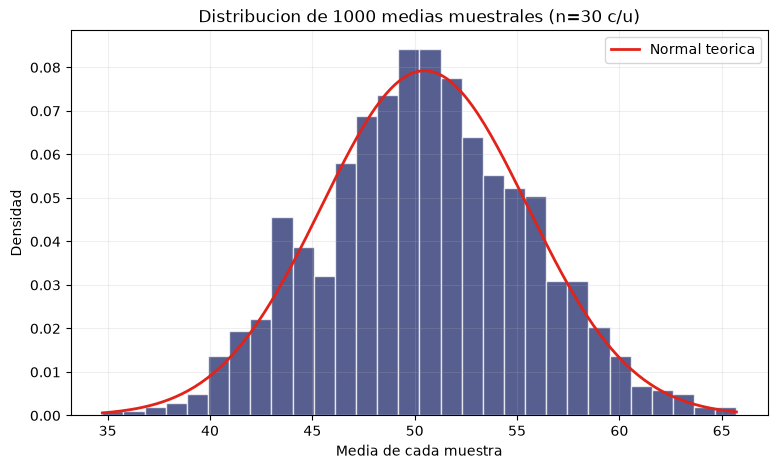

Media de la poblacion original: 49.95
Media de las medias muestrales: 50.48
Observa: aunque la poblacion era UNIFORME, las medias forman una CAMPANA.


In [15]:
# Ahora tomamos MUCHAS muestras y guardamos la MEDIA de cada una
tamano_muestra   = 30      # cuantos datos tiene cada muestra
numero_muestras  = 1000    # cuantas muestras tomamos

medias_muestrales = []
for _ in range(numero_muestras):
    muestra = np.random.choice(poblacion, size=tamano_muestra)
    medias_muestrales.append(np.mean(muestra))

medias_muestrales = np.array(medias_muestrales)

plt.figure(figsize=(9,5))
plt.hist(medias_muestrales, bins=30, color="#1e2a6b", alpha=0.75,
         edgecolor="white", density=True)

# Superponemos la normal teorica que predice el TLC
x = np.linspace(medias_muestrales.min(), medias_muestrales.max(), 200)
plt.plot(x, stats.norm.pdf(x, medias_muestrales.mean(), medias_muestrales.std()),
         color="#e2231a", linewidth=2, label="Normal teorica")
plt.title(f"Distribucion de {numero_muestras} medias muestrales (n={tamano_muestra} c/u)")
plt.xlabel("Media de cada muestra")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"Media de la poblacion original: {poblacion.mean():.2f}")
print(f"Media de las medias muestrales: {medias_muestrales.mean():.2f}")
print("Observa: aunque la poblacion era UNIFORME, las medias forman una CAMPANA.")

> ✍️ **Pregunta 5.1** — Compara las dos gráficas. La población original era plana (uniforme), pero la distribución de las medias muestrales tiene forma de campana. Explica con tus palabras qué demuestra esto y por qué es tan poderoso para la estadística inferencial.

**Respuesta:** Demuestra el teorema del límite central: no importa qué forma tenga la distribución original (aquí era totalmente plana), las medias de las muestras se acomodan en una campana normal. Es poderoso porque permite usar toda la teoría de la distribución normal —intervalos de confianza, pruebas de hipótesis, márgenes de error— aunque no sepamos ni nos importe cómo se distribuyen los datos originales.

> ✍️ **Pregunta 5.2** — La media de la población y la media de las medias muestrales son casi idénticas. ¿Es esto una coincidencia? ¿Qué implica para estimar el valor real de una población a partir de muestras?

**Respuesta:** No es coincidencia: en promedio, la media de las muestras tiende a coincidir con la media real de la población (es un estimador insesgado). Implica que no necesitamos medir a toda la población para conocer su promedio: con muestras bien tomadas podemos estimar el valor real, y entre más muestras o más grandes, más nos acercamos.

### 🔧 Reto de modificación 4

Cambia el `tamano_muestra` de la celda anterior a valores pequeños (por ejemplo **2** y **5**) y luego a valores grandes (**50** y **100**). Vuelve a ejecutar cada vez y observa la forma de la campana.


In [16]:
# RETO: experimenta con distintos tamanos de muestra y compara visualmente
# Ejecuta esta celda con distintos valores en la lista

for tamano in [2, 5, 30, 100]:
    medias = [np.mean(np.random.choice(poblacion, size=tamano)) for _ in range(1000)]
    medias = np.array(medias)
    print(f"n={tamano:3d}  ->  desviacion estandar de las medias = {medias.std():.2f}")

print()
print("Conclusion: a mayor tamano de muestra, MENOR es la dispersion de las medias")
print("(la campana se vuelve mas angosta y la estimacion mas precisa).")

n=  2  ->  desviacion estandar de las medias = 20.50
n=  5  ->  desviacion estandar de las medias = 13.16
n= 30  ->  desviacion estandar de las medias = 5.08
n=100  ->  desviacion estandar de las medias = 2.85

Conclusion: a mayor tamano de muestra, MENOR es la dispersion de las medias
(la campana se vuelve mas angosta y la estimacion mas precisa).


> ✍️ **Pregunta 5.3** — Según la salida anterior, ¿qué le pasa a la dispersión (desviación estándar) de las medias muestrales cuando aumenta el tamaño de muestra? Conecta esto con una decisión práctica: ¿por qué las encuestas serias usan muestras grandes?

**Respuesta:** La dispersión cae conforme crece la muestra: de 20.5 con n=2 bajó hasta 2.9 con n=100. Con muestras chicas cada media puede salir muy lejos del valor real; con muestras grandes las medias se concentran alrededor de él. Por eso las encuestas serias usan muestras grandes: reducen el margen de error y la estimación se vuelve confiable, en vez de depender de la suerte de a quién les tocó preguntar.

---
## Paso 6 — Cierre: reto integrador

Ahora aplica todo lo aprendido de forma autónoma.


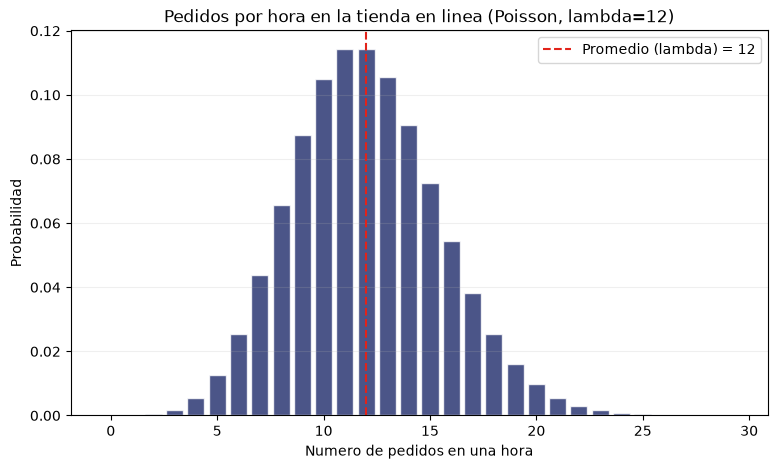

b) P(exactamente 12 pedidos) = 0.114  ->  11.4%
c) P(mas de 20 pedidos)      = 0.0116  ->  1.16%


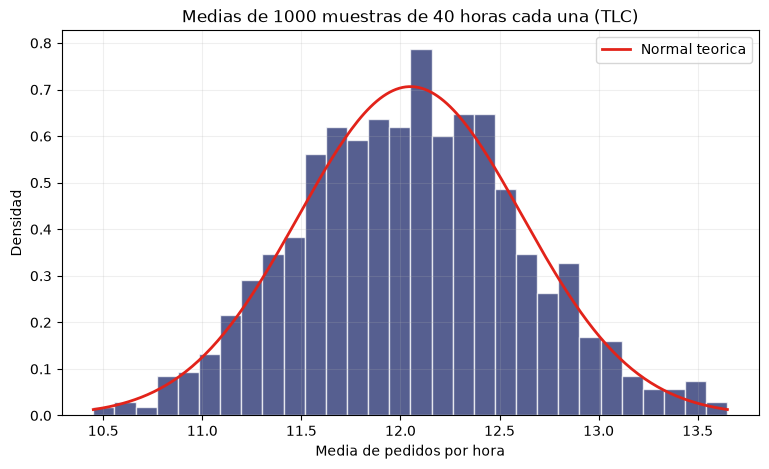

d) Media de las medias muestrales = 12.05  (lambda real = 12)
   La distribucion de las medias forma una campana: se cumple el TLC.


In [17]:
# RETO INTEGRADOR
# Una tienda en linea recibe en promedio 12 pedidos por hora (Poisson).

lam = 12   # pedidos por hora

# a) Grafica de la distribucion de Poisson
k = np.arange(0, 30)
plt.figure(figsize=(9,5))
plt.bar(k, stats.poisson.pmf(k, lam), color="#1e2a6b", alpha=0.8, edgecolor="white")
plt.axvline(lam, color="#e2231a", linestyle="--", label=f"Promedio (lambda) = {lam}")
plt.title(f"Pedidos por hora en la tienda en linea (Poisson, lambda={lam})")
plt.xlabel("Numero de pedidos en una hora")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(alpha=0.2, axis="y")
plt.show()

# b) Probabilidad de recibir exactamente 12 pedidos en una hora
p_12 = stats.poisson.pmf(12, lam)
print(f"b) P(exactamente 12 pedidos) = {p_12:.3f}  ->  {p_12*100:.1f}%")

# c) Probabilidad de recibir mas de 20 pedidos (posible saturacion)
p_mas_20 = 1 - stats.poisson.cdf(20, lam)
print(f"c) P(mas de 20 pedidos)      = {p_mas_20:.4f}  ->  {p_mas_20*100:.2f}%")

# d) TLC: 1000 muestras de 40 horas cada una y la media de cada muestra
medias = np.array([np.mean(stats.poisson.rvs(lam, size=40)) for _ in range(1000)])

plt.figure(figsize=(9,5))
plt.hist(medias, bins=30, color="#1e2a6b", alpha=0.75, edgecolor="white", density=True)
x = np.linspace(medias.min(), medias.max(), 200)
plt.plot(x, stats.norm.pdf(x, medias.mean(), medias.std()),
         color="#e2231a", linewidth=2, label="Normal teorica")
plt.title("Medias de 1000 muestras de 40 horas cada una (TLC)")
plt.xlabel("Media de pedidos por hora")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"d) Media de las medias muestrales = {medias.mean():.2f}  (lambda real = {lam})")
print("   La distribucion de las medias forma una campana: se cumple el TLC.")

> ✍️ **Pregunta 6.1** — Interpreta tus resultados del reto integrador. ¿La tienda debería preocuparse por la saturación? Justifica con los números que obtuviste.

**Respuesta:** No demasiado. La probabilidad de pasar de 20 pedidos en una hora es de **1.16%**, o sea más o menos 1 hora de cada 86 (menos de una vez cada 3 días de operación continua). Con un pequeño margen de inventario extra se cubre ese pico ocasional. Además, el escenario más probable es el promedio: recibir exactamente 12 pedidos tiene probabilidad de 11.4%, y el TLC mostró que la media por muestra de 40 horas se mantiene estable alrededor de 12. Eso sí: si el promedio de pedidos crece, habría que rehacer este cálculo, porque como vimos con el servidor, la saturación puede dispararse rápido.

> ✍️ **Reflexión final** — De los cuatro temas trabajados (medidas descriptivas, normal, binomial, Poisson y TLC), ¿cuál te costó más entender y cuál crees que aplicarás con más frecuencia en tu carrera de Ingeniería en Computación? Explica.

**Respuesta:** El que más me costó fue el teorema del límite central: entender por qué las medias forman una campana aunque los datos originales no se parezcan en nada a una normal no es intuitivo, y lo que me lo aclaró fue verlo graficado en el experimento, no la teoría. El que creo que más voy a aplicar es la distribución de Poisson, porque modela exactamente los problemas que veo en computación: solicitudes a un servidor, tráfico de red, llegadas a una cola. Saber calcular la probabilidad de saturación es directamente una herramienta para dimensionar sistemas. Y las medidas descriptivas las usaré todo el tiempo, porque cualquier análisis de datos empieza por ahí.

---
## Entrega en Google Classroom

1. Verifica que **todas las celdas de código se ejecuten sin error** (Entorno de ejecución → Ejecutar todas).
2. Confirma que respondiste **todas** las preguntas ✍️ y la reflexión final.
3. Ve a **Archivo → Guardar una copia en Drive**.
4. Comparte el enlace del cuaderno (con permiso de lectura) en la tarea de Classroom.

### Criterios de evaluación

| Criterio | Puntos |
|---|---|
| Todas las celdas se ejecutan correctamente | 20 |
| Retos de modificación completados | 25 |
| Respuestas a las preguntas ✍️ (claridad y correccion) | 30 |
| Reto integrador (Paso 6) resuelto | 15 |
| Reflexión final argumentada | 10 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
